C:\Users\shiha\AppData\Local\Temp\ipykernel_19644\1098719507.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Image Count', y='Disease Class', data=df, palette='viridis')


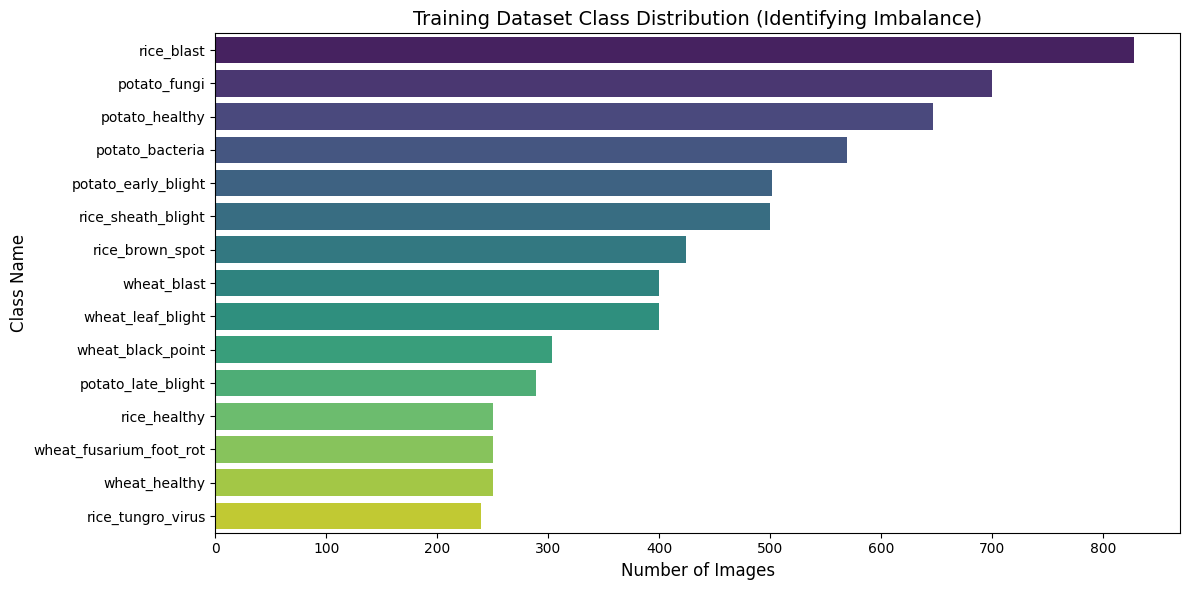

--- Raw Training Data Counts ---
          Disease Class  Image Count
             rice_blast          828
           potato_fungi          700
         potato_healthy          647
        potato_bacteria          569
    potato_early_blight          502
     rice_sheath_blight          500
        rice_brown_spot          424
            wheat_blast          400
      wheat_leaf_blight          400
      wheat_black_point          303
     potato_late_blight          289
           rice_healthy          250
wheat_fusarium_foot_rot          250
          wheat_healthy          250
      rice_tungro_virus          239


In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the path to your training data
train_dir = r"D:\00" 

# 2. Count images in each class
classes = os.listdir(train_dir)
image_counts = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)
    count = len(os.listdir(class_path))
    image_counts.append(count)

# 3. Create a table (DataFrame) for easy viewing and plotting
df = pd.DataFrame({'Disease Class': classes, 'Image Count': image_counts})
df = df.sort_values(by='Image Count', ascending=False)

# 4. Plot the distribution
plt.figure(figsize=(12, 6))
sns.barplot(x='Image Count', y='Disease Class', data=df, palette='viridis')
plt.title('Training Dataset Class Distribution (Identifying Imbalance)', fontsize=14)
plt.xlabel('Number of Images', fontsize=12)
plt.ylabel('Class Name', fontsize=12)
plt.tight_layout()

# Save the plot so you can put it in your thesis document later
plt.savefig(r"D:\00_Final_Split\class_distribution_chart.png")
plt.show()

# 5. Print the raw numbers for documentation
print("--- Raw Training Data Counts ---")
print(df.to_string(index=False))

In [3]:
import os
import pandas as pd

# The absolute beginning: Your main raw dataset folder
main_dataset_path = r"D:\00"

print(f"📂 Auditing raw dataset at: {main_dataset_path}\n")

# Get all class folders
classes = sorted(os.listdir(main_dataset_path))
total_images = 0
data_info = []

print("--- Original Dataset Breakdown ---")
for cls in classes:
    folder_path = os.path.join(main_dataset_path, cls)
    
    # Count only the image files inside each folder
    if os.path.isdir(folder_path):
        count = len([f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))])
        data_info.append({'Class': cls, 'Count': count})
        total_images += count
        print(f" -> {cls}: {count} images")

print("-" * 35)
print(f"Total Disease Classes: {len(classes)}")
print(f"Total Raw Images: {total_images}")

# Optional: Find the biggest and smallest classes to highlight the imbalance mathematically
counts = [item['Count'] for item in data_info]
print(f"\n⚠️ Imbalance Check:")
print(f"Largest class has {max(counts)} images.")
print(f"Smallest class has {min(counts)} images.")

📂 Auditing raw dataset at: D:\00

--- Original Dataset Breakdown ---
 -> potato_bacteria: 569 images
 -> potato_early_blight: 502 images
 -> potato_fungi: 700 images
 -> potato_healthy: 647 images
 -> potato_late_blight: 289 images
 -> rice_blast: 828 images
 -> rice_brown_spot: 424 images
 -> rice_healthy: 250 images
 -> rice_sheath_blight: 500 images
 -> rice_tungro_virus: 239 images
 -> wheat_black_point: 303 images
 -> wheat_blast: 400 images
 -> wheat_fusarium_foot_rot: 250 images
 -> wheat_healthy: 250 images
 -> wheat_leaf_blight: 400 images
-----------------------------------
Total Disease Classes: 15
Total Raw Images: 6551

⚠️ Imbalance Check:
Largest class has 828 images.
Smallest class has 239 images.


In [1]:
import splitfolders
import os

# 1. Define Paths
input_folder = r"D:\00"
output_folder = r"D:\00_Thesis_Split" # Brand new, clean folder

print(f"✂️ Starting Stratified Split from {input_folder}...")
print(f"Creating new directories in {output_folder}...")

# 2. Execute the Split (80% Train, 10% Val, 10% Test)
# seed=42 ensures that if you run this again, it splits exactly the same way (reproducibility)
splitfolders.ratio(
    input_folder, 
    output=output_folder, 
    seed=42, 
    ratio=(0.8, 0.1, 0.1), 
    group_prefix=None, 
    move=False # We copy the files, keeping your original D:\00 completely safe
)

print("\n✅ Splitting Complete!")

# 3. Verify the newly created folders
train_dir = os.path.join(output_folder, "train")
val_dir = os.path.join(output_folder, "val")
test_dir = os.path.join(output_folder, "test")

def count_files(directory):
    total = 0
    for root, dirs, files in os.walk(directory):
        total += len(files)
    return total

print("-" * 35)
print("--- New Dataset Verification ---")
print(f"Training Images: {count_files(train_dir)}")
print(f"Validation Images: {count_files(val_dir)}")
print(f"Testing Images: {count_files(test_dir)}")
print("Data Leakage Risk: ELIMINATED.")

✂️ Starting Stratified Split from D:\00...
Creating new directories in D:\00_Thesis_Split...

✅ Splitting Complete!
-----------------------------------
--- New Dataset Verification ---
Training Images: 5238
Validation Images: 650
Testing Images: 663
Data Leakage Risk: ELIMINATED.


In [2]:
import numpy as np
import os
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Define the NEW Safe Paths
train_dir = r"D:\00_Thesis_Split\train"
val_dir = r"D:\00_Thesis_Split\val"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# 2. Calculate Class Weights (ONLY on the 5,238 training images)
classes = sorted(os.listdir(train_dir))
image_counts = [len(os.listdir(os.path.join(train_dir, cls))) for cls in classes]
num_classes = len(classes)

weights = compute_class_weight(
    class_weight='balanced', 
    classes=np.arange(num_classes), 
    y=np.repeat(np.arange(num_classes), image_counts)
)

class_weights_dict = dict(zip(np.arange(num_classes), weights))

print("--- Thesis Documentation: Class Weights (Train Set Only) ---")
for i, cls in enumerate(classes):
    print(f"{cls}: {weights[i]:.2f}")

# 3. Setup Augmentation (The Imbalance & Overfitting Fix)
print("\n--- Initializing Data Pipelines ---")

# Training gets augmented to create infinite synthetic variations
train_datagen = ImageDataGenerator(
    rescale=1./255,          # Standardize pixel values to 0-1
    rotation_range=20,       # Randomly rotate images
    width_shift_range=0.1,   # Randomly shift left/right
    height_shift_range=0.1,  # Randomly shift up/down
    zoom_range=0.1,          # Randomly zoom in/out
    horizontal_flip=True,    # Randomly flip horizontally
    fill_mode='nearest'
)

# Validation MUST remain pure (only rescaling, NO rotation or zooming)
val_datagen = ImageDataGenerator(rescale=1./255)

# 4. Connect the Generators to the Safe Folders
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True # Shuffle training data so the model doesn't memorize the order
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # NEVER shuffle validation data
)

--- Thesis Documentation: Class Weights (Train Set Only) ---
potato_bacteria: 0.77
potato_early_blight: 0.87
potato_fungi: 0.62
potato_healthy: 0.68
potato_late_blight: 1.51
rice_blast: 0.53
rice_brown_spot: 1.03
rice_healthy: 1.75
rice_sheath_blight: 0.87
rice_tungro_virus: 1.83
wheat_black_point: 1.44
wheat_blast: 1.09
wheat_fusarium_foot_rot: 1.75
wheat_healthy: 1.75
wheat_leaf_blight: 1.09

--- Initializing Data Pipelines ---
Found 5238 images belonging to 15 classes.
Found 650 images belonging to 15 classes.


In [3]:
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("🏗️ Building Model 1: DenseNet121...")

# 1. Load the Base Model (Transfer Learning)
base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model to train only our custom top layers first
base_model.trainable = False

# 2. Add Custom Classification Head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)  # Helps stabilize training
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)          # 40% Dropout to prevent overfitting on minority classes
predictions = Dense(15, activation='softmax')(x) # 15 Crop Disease Classes

model_dense = Model(inputs=base_model.input, outputs=predictions)

# 3. Compile the Model
# We use a slightly smaller learning rate (0.001) for stable learning
model_dense.compile(optimizer=Adam(learning_rate=0.001), 
                    loss='categorical_crossentropy', 
                    metrics=['accuracy'])

# 4. Setup Callbacks (The Safety Nets)
checkpoint = ModelCheckpoint(
    r"D:\00_Thesis_Split\DenseNet121_Best.keras", 
    save_best_only=True, 
    monitor='val_accuracy', 
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5,             # Stop if val_loss doesn't improve for 5 epochs
    restore_best_weights=True,
    verbose=1
)

# Slow down learning rate if it gets stuck
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6, 
    verbose=1
)

# 5. Start Training!
print("\n🚀 Starting Training: DenseNet121 Phase 1 (Frozen Base)")
print("Applying class weights to handle imbalance...")

history_dense = model_dense.fit(
    train_generator,
    epochs=20, # 20 epochs is a good limit, EarlyStopping will likely catch it sooner
    validation_data=val_generator,
    class_weight=class_weights_dict, # ⚠️ This is where the imbalance fix happens!
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

print("\n✅ DenseNet121 Initial Training Complete.")

🏗️ Building Model 1: DenseNet121...

🚀 Starting Training: DenseNet121 Phase 1 (Frozen Base)
Applying class weights to handle imbalance...
Epoch 1/20
328/328 [==============================] - ETA: 0s - loss: 0.6994 - accuracy: 0.7524
Epoch 1: val_accuracy improved from -inf to 0.86154, saving model to D:\00_Thesis_Split\DenseNet121_Best.keras
328/328 [==============================] - 295s 820ms/step - loss: 0.6994 - accuracy: 0.7524 - val_loss: 0.3857 - val_accuracy: 0.8615 - lr: 0.0010
Epoch 2/20
328/328 [==============================] - ETA: 0s - loss: 0.3737 - accuracy: 0.8499
Epoch 2: val_accuracy improved from 0.86154 to 0.88769, saving model to D:\00_Thesis_Split\DenseNet121_Best.keras
328/328 [==============================] - 166s 506ms/step - loss: 0.3737 - accuracy: 0.8499 - val_loss: 0.3218 - val_accuracy: 0.8877 - lr: 0.0010
Epoch 3/20
328/328 [==============================] - ETA: 0s - loss: 0.3065 - accuracy: 0.8795
Epoch 3: val_accuracy improved from 0.88769 to 0.9153

📝 Initiating Final Exam (Test Set Evaluation) for DenseNet121...
Found 663 images belonging to 15 classes.

📊 Running standard evaluation...
42/42 [==============================] - 28s 558ms/step - loss: 0.2049 - accuracy: 0.9367
🏆 DenseNet121 Unbiased Test Accuracy: 93.67%

🔍 Generating detailed predictions...
42/42 [==============================] - 13s 223ms/step

--- Thesis Documentation: Classification Report ---
                         precision    recall  f1-score   support

        potato_bacteria       0.98      0.97      0.97        58
    potato_early_blight       1.00      1.00      1.00        51
           potato_fungi       0.94      0.89      0.91        70
         potato_healthy       0.89      0.97      0.93        66
     potato_late_blight       1.00      0.97      0.98        30
             rice_blast       0.90      0.88      0.89        84
        rice_brown_spot       0.89      0.91      0.90        43
           rice_healthy       0.86      0.76      0.81  

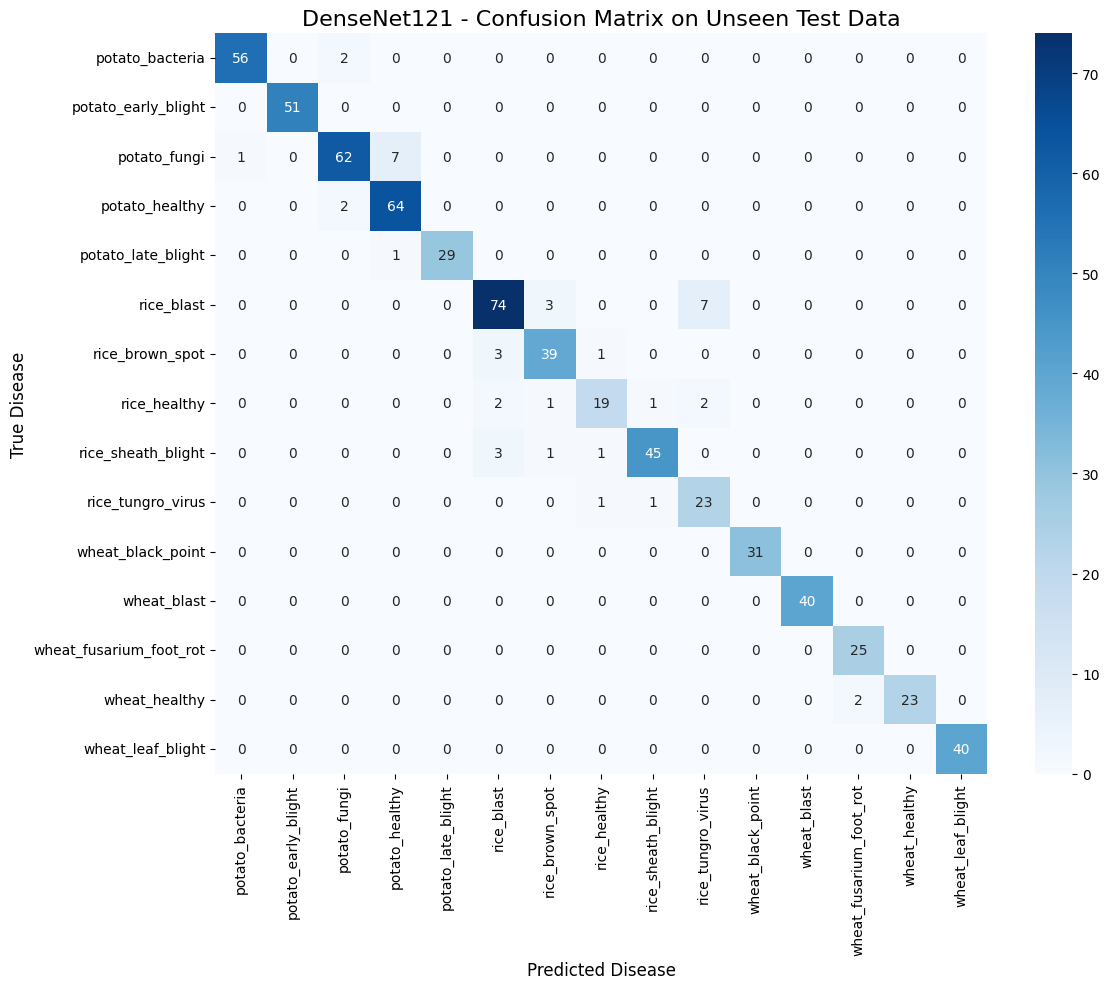

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

print("📝 Initiating Final Exam (Test Set Evaluation) for DenseNet121...")

# 1. Define Test Path and load the strictly pure test data
test_dir = r"D:\00_Thesis_Split\test"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# ONLY rescaling. No augmentation, NO shuffling. 
# We must keep them in exact order to match the predictions with the real labels!
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False 
)

# 2. Load the best saved DenseNet model
model_path = r"D:\00_Thesis_Split\DenseNet121_Best.keras"
best_dense_model = load_model(model_path)

# 3. Get overall Accuracy and Loss
print("\n📊 Running standard evaluation...")
test_loss, test_acc = best_dense_model.evaluate(test_generator, verbose=1)
print(f"🏆 DenseNet121 Unbiased Test Accuracy: {test_acc * 100:.2f}%")

# 4. Generate Predictions for the Detailed Report
print("\n🔍 Generating detailed predictions...")
predictions = best_dense_model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# 5. Print Classification Report
print("\n--- Thesis Documentation: Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# 6. Plot and Save the Confusion Matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('DenseNet121 - Confusion Matrix on Unseen Test Data', fontsize=16)
plt.ylabel('True Disease', fontsize=12)
plt.xlabel('Predicted Disease', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

# Save this image directly to your folder for the thesis document
plt.savefig(r"D:\00_Thesis_Split\DenseNet121_Confusion_Matrix.png")
print("✅ Confusion Matrix saved to D:\\00_Thesis_Split\\DenseNet121_Confusion_Matrix.png")
plt.show()

In [8]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("🏗️ Building Model 2: EfficientNetB0 (The Lightweight Challenger)...")

# 1. Pure Python Class Weights
pure_class_weights = {int(k): float(v) for k, v in class_weights_dict.items()}

# 2. Load the Base Model
base_model_eff = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_eff.trainable = False

# 3. Add Custom Classification Head
x = base_model_eff.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
predictions_eff = Dense(15, activation='softmax')(x)

model_eff = Model(inputs=base_model_eff.input, outputs=predictions_eff)

# 4. Compile the Model
model_eff.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])

# --- THE MAGIC FIX IS HERE ---
# We save ONLY the weights as a simple .h5 file. No JSON serialization required!
checkpoint_eff = ModelCheckpoint(
    filepath=r"D:\00_Thesis_Split\EfficientNet_Best_Weights.h5", 
    save_weights_only=True,   # <--- This bypasses the crash completely
    save_best_only=True, 
    monitor='val_accuracy', 
    verbose=1
)

early_stop_eff = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

reduce_lr_eff = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6, 
    verbose=1
)

# 5. Train EfficientNet
print("\n🚀 Starting Training: EfficientNetB0 Phase 1")
history_eff = model_eff.fit(
    train_generator,
    epochs=20, 
    validation_data=val_generator,
    class_weight=pure_class_weights, 
    callbacks=[checkpoint_eff, early_stop_eff, reduce_lr_eff],
    verbose=1
)

print("\n✅ EfficientNetB0 Initial Training Complete.")

🏗️ Building Model 2: EfficientNetB0 (The Lightweight Challenger)...

🚀 Starting Training: EfficientNetB0 Phase 1
Epoch 1/20
328/328 [==============================] - ETA: 0s - loss: 3.2571 - accuracy: 0.0645
Epoch 1: val_accuracy improved from -inf to 0.04308, saving model to D:\00_Thesis_Split\EfficientNet_Best_Weights.h5
328/328 [==============================] - 87s 249ms/step - loss: 3.2571 - accuracy: 0.0645 - val_loss: 2.7063 - val_accuracy: 0.0431 - lr: 0.0010
Epoch 2/20
328/328 [==============================] - ETA: 0s - loss: 2.8730 - accuracy: 0.0764
Epoch 2: val_accuracy did not improve from 0.04308
328/328 [==============================] - 79s 240ms/step - loss: 2.8730 - accuracy: 0.0764 - val_loss: 2.7025 - val_accuracy: 0.0400 - lr: 0.0010
Epoch 3/20
328/328 [==============================] - ETA: 0s - loss: 2.7358 - accuracy: 0.0729
Epoch 3: val_accuracy improved from 0.04308 to 0.05385, saving model to D:\00_Thesis_Split\EfficientNet_Best_Weights.h5
328/328 [========

In [9]:
print("⚡ Phase 2: Unfreezing EfficientNetB0 (Fine-Tuning)...")

# 1. Load the weights from the 18% model we just trained
model_eff.load_weights(r"D:\00_Thesis_Split\EfficientNet_Best_Weights.h5")

# 2. UNFREEZE the base model
# This allows the core architecture to adjust to the double-scaled pixels and agricultural data
base_model_eff.trainable = True

# 3. Re-compile with a MUCH slower learning rate
# If we use a fast learning rate now, it will destroy the model completely
model_eff.compile(optimizer=Adam(learning_rate=1e-4), # 10x slower than before
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])

# 4. Setup Callbacks for Phase 2
checkpoint_eff_fine = ModelCheckpoint(
    filepath=r"D:\00_Thesis_Split\EfficientNet_FineTuned_Weights.h5", 
    save_weights_only=True,
    save_best_only=True, 
    monitor='val_accuracy', 
    verbose=1
)

early_stop_eff_fine = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

# 5. Train the Unfrozen Model
print("\n🚀 Starting Fine-Tuning: EfficientNetB0 Phase 2")
history_eff_fine = model_eff.fit(
    train_generator,
    epochs=15, 
    validation_data=val_generator,
    class_weight=pure_class_weights, 
    callbacks=[checkpoint_eff_fine, early_stop_eff_fine],
    verbose=1
)

print("\n✅ EfficientNetB0 Fine-Tuning Complete.")

⚡ Phase 2: Unfreezing EfficientNetB0 (Fine-Tuning)...

🚀 Starting Fine-Tuning: EfficientNetB0 Phase 2
Epoch 1/15
328/328 [==============================] - ETA: 0s - loss: 1.9421 - accuracy: 0.3515
Epoch 1: val_accuracy improved from -inf to 0.06923, saving model to D:\00_Thesis_Split\EfficientNet_FineTuned_Weights.h5
328/328 [==============================] - 93s 240ms/step - loss: 1.9421 - accuracy: 0.3515 - val_loss: 3.1111 - val_accuracy: 0.0692
Epoch 2/15
328/328 [==============================] - ETA: 0s - loss: 0.7866 - accuracy: 0.7104
Epoch 2: val_accuracy improved from 0.06923 to 0.58615, saving model to D:\00_Thesis_Split\EfficientNet_FineTuned_Weights.h5
328/328 [==============================] - 80s 242ms/step - loss: 0.7866 - accuracy: 0.7104 - val_loss: 1.3367 - val_accuracy: 0.5862
Epoch 3/15
328/328 [==============================] - ETA: 0s - loss: 0.4819 - accuracy: 0.8171
Epoch 3: val_accuracy did not improve from 0.58615
328/328 [==============================] - 1

📝 Initiating Final Exam (Test Set Evaluation) for EfficientNetB0...
Found 663 images belonging to 15 classes.

📊 Running standard evaluation...
42/42 [==============================] - 15s 334ms/step - loss: 0.3745 - accuracy: 0.8627
🏆 EfficientNetB0 Unbiased Test Accuracy: 86.27%

🔍 Generating detailed predictions...
42/42 [==============================] - 18s 288ms/step

--- Thesis Documentation: EfficientNet Classification Report ---
                         precision    recall  f1-score   support

        potato_bacteria       0.90      0.93      0.92        58
    potato_early_blight       0.98      1.00      0.99        51
           potato_fungi       0.98      0.83      0.90        70
         potato_healthy       0.89      0.94      0.91        66
     potato_late_blight       0.97      0.93      0.95        30
             rice_blast       0.77      0.77      0.77        84
        rice_brown_spot       0.85      0.77      0.80        43
           rice_healthy       0.53   

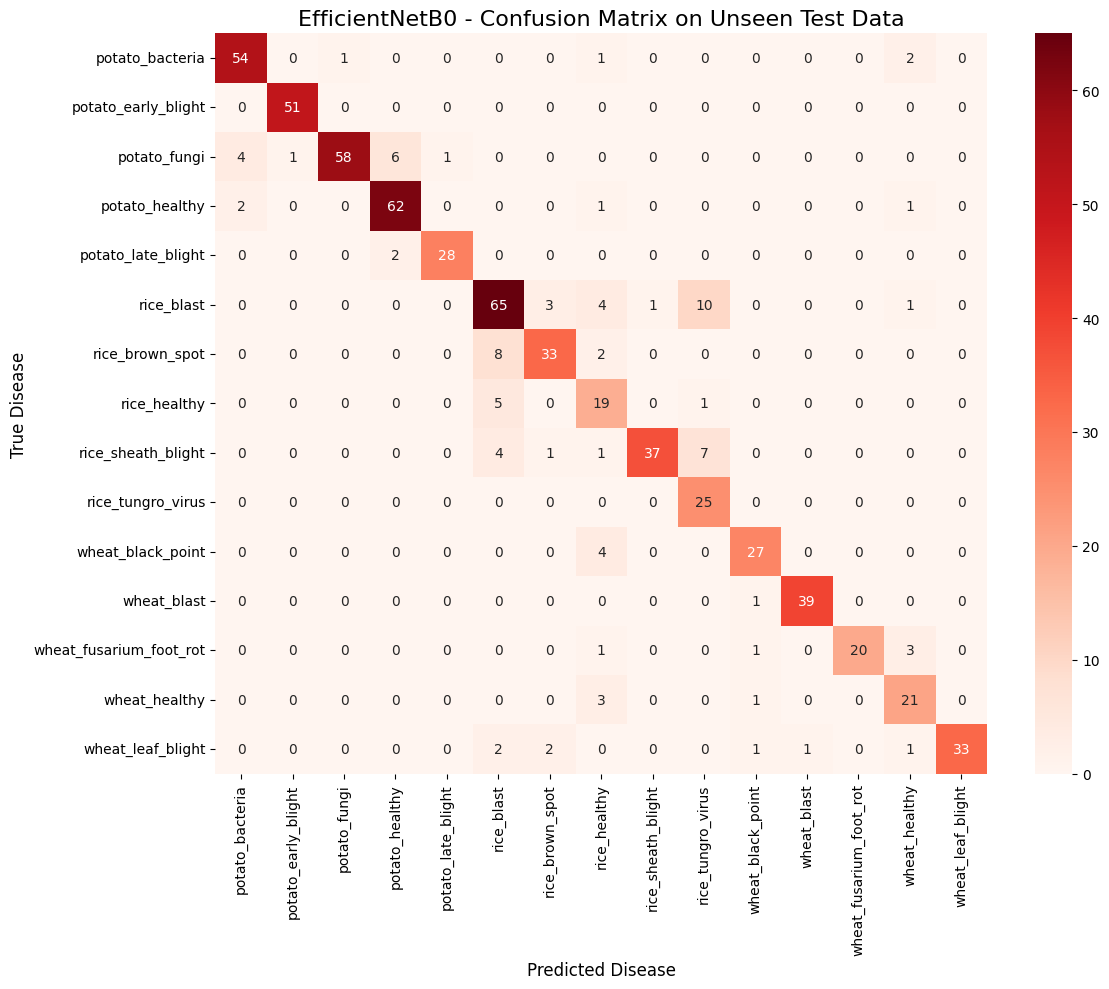

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import os

print("📝 Initiating Final Exam (Test Set Evaluation) for EfficientNetB0...")

# 1. We must explicitly load the BEST weights we saved at Epoch 6
# (Since the model finished at Epoch 11, we want the 86% version, not the 70% version)
model_eff.load_weights(r"D:\00_Thesis_Split\EfficientNet_FineTuned_Weights.h5")

# 2. Re-initialize the Test Generator just to be 100% safe
test_dir = r"D:\00_Thesis_Split\test"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False # NEVER SHUFFLE TEST DATA
)

# 3. Get overall Accuracy and Loss
print("\n📊 Running standard evaluation...")
test_loss_eff, test_acc_eff = model_eff.evaluate(test_generator, verbose=1)
print(f"🏆 EfficientNetB0 Unbiased Test Accuracy: {test_acc_eff * 100:.2f}%")

# 4. Generate Predictions for the Detailed Report
print("\n🔍 Generating detailed predictions...")
predictions_eff = model_eff.predict(test_generator, verbose=1)
y_pred_eff = np.argmax(predictions_eff, axis=1)
y_true_eff = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# 5. Print Classification Report
print("\n--- Thesis Documentation: EfficientNet Classification Report ---")
print(classification_report(y_true_eff, y_pred_eff, target_names=class_names))

# 6. Plot and Save the Confusion Matrix
plt.figure(figsize=(12, 10))
cm_eff = confusion_matrix(y_true_eff, y_pred_eff)
sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Reds', xticklabels=class_names, yticklabels=class_names)
plt.title('EfficientNetB0 - Confusion Matrix on Unseen Test Data', fontsize=16)
plt.ylabel('True Disease', fontsize=12)
plt.xlabel('Predicted Disease', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

# Save this image directly to your folder for the thesis document
plt.savefig(r"D:\00_Thesis_Split\EfficientNet_Confusion_Matrix.png")
print("✅ Confusion Matrix saved to D:\\00_Thesis_Split\\EfficientNet_Confusion_Matrix.png")
plt.show()

In [11]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("🏗️ Building Model 3: MobileNetV2 (The Mobile Champion)...")

# 1. Load the Base Model
# Notice the input shape is 224x224, standard for MobileNet
base_model_mobile = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model_mobile.trainable = False

# 2. Add Custom Classification Head
x = base_model_mobile.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
predictions_mobile = Dense(15, activation='softmax')(x)

model_mobile = Model(inputs=base_model_mobile.input, outputs=predictions_mobile)

# 3. Compile the Model
model_mobile.compile(optimizer=Adam(learning_rate=0.001), 
                     loss='categorical_crossentropy', 
                     metrics=['accuracy'])

# 4. Setup Callbacks
checkpoint_mobile = ModelCheckpoint(
    filepath=r"D:\00_Thesis_Split\MobileNetV2_Best_Weights.h5", 
    save_weights_only=True, 
    save_best_only=True, 
    monitor='val_accuracy', 
    verbose=1
)

early_stop_mobile = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

reduce_lr_mobile = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.2, 
    patience=3, 
    min_lr=1e-6, 
    verbose=1
)

# 5. Train MobileNetV2
print("\n🚀 Starting Training: MobileNetV2 Phase 1 (Frozen Base)")
history_mobile = model_mobile.fit(
    train_generator,
    epochs=20, 
    validation_data=val_generator,
    class_weight=pure_class_weights, # Applying our golden imbalance fix
    callbacks=[checkpoint_mobile, early_stop_mobile, reduce_lr_mobile],
    verbose=1
)

print("\n✅ MobileNetV2 Initial Training Complete.")

🏗️ Building Model 3: MobileNetV2 (The Mobile Champion)...

🚀 Starting Training: MobileNetV2 Phase 1 (Frozen Base)
Epoch 1/20
328/328 [==============================] - ETA: 0s - loss: 0.8700 - accuracy: 0.7129
Epoch 1: val_accuracy improved from -inf to 0.84615, saving model to D:\00_Thesis_Split\MobileNetV2_Best_Weights.h5
328/328 [==============================] - 211s 615ms/step - loss: 0.8700 - accuracy: 0.7129 - val_loss: 0.4493 - val_accuracy: 0.8462 - lr: 0.0010
Epoch 2/20
328/328 [==============================] - ETA: 0s - loss: 0.5144 - accuracy: 0.8226
Epoch 2: val_accuracy improved from 0.84615 to 0.84769, saving model to D:\00_Thesis_Split\MobileNetV2_Best_Weights.h5
328/328 [==============================] - 183s 556ms/step - loss: 0.5144 - accuracy: 0.8226 - val_loss: 0.4566 - val_accuracy: 0.8477 - lr: 0.0010
Epoch 3/20
328/328 [==============================] - ETA: 0s - loss: 0.4037 - accuracy: 0.8545
Epoch 3: val_accuracy improved from 0.84769 to 0.86000, saving mode

In [12]:
print("⚡ Phase 2: Unfreezing MobileNetV2 (Fine-Tuning)...")

# 1. Load the absolute best weights from Phase 1 (Epoch 13)
model_mobile.load_weights(r"D:\00_Thesis_Split\MobileNetV2_Best_Weights.h5")

# 2. UNFREEZE the base model
# Now the whole network will learn the specific textures of crop leaves
base_model_mobile.trainable = True

# 3. Re-compile with a VERY SLOW learning rate (1e-5)
# If we use a fast rate now, it will destroy the 91% accuracy we just built.
model_mobile.compile(optimizer=Adam(learning_rate=1e-5), 
                     loss='categorical_crossentropy', 
                     metrics=['accuracy'])

# 4. Setup Callbacks for Phase 2
checkpoint_mobile_fine = ModelCheckpoint(
    filepath=r"D:\00_Thesis_Split\MobileNetV2_FineTuned_Weights.h5", 
    save_weights_only=True,
    save_best_only=True, 
    monitor='val_accuracy', 
    verbose=1
)

early_stop_mobile_fine = EarlyStopping(
    monitor='val_loss', 
    patience=5, 
    restore_best_weights=True,
    verbose=1
)

# 5. Train the Unfrozen Model
print("\n🚀 Starting Fine-Tuning: MobileNetV2 Phase 2")
history_mobile_fine = model_mobile.fit(
    train_generator,
    epochs=15, 
    validation_data=val_generator,
    class_weight=pure_class_weights, 
    callbacks=[checkpoint_mobile_fine, early_stop_mobile_fine],
    verbose=1
)

print("\n✅ MobileNetV2 Fine-Tuning Complete.")

⚡ Phase 2: Unfreezing MobileNetV2 (Fine-Tuning)...

🚀 Starting Fine-Tuning: MobileNetV2 Phase 2
Epoch 1/15
328/328 [==============================] - ETA: 0s - loss: 0.7966 - accuracy: 0.7467
Epoch 1: val_accuracy improved from -inf to 0.88769, saving model to D:\00_Thesis_Split\MobileNetV2_FineTuned_Weights.h5
328/328 [==============================] - 178s 503ms/step - loss: 0.7966 - accuracy: 0.7467 - val_loss: 0.3668 - val_accuracy: 0.8877
Epoch 2/15
328/328 [==============================] - ETA: 0s - loss: 0.5620 - accuracy: 0.8039
Epoch 2: val_accuracy did not improve from 0.88769
328/328 [==============================] - 162s 492ms/step - loss: 0.5620 - accuracy: 0.8039 - val_loss: 0.4088 - val_accuracy: 0.8800
Epoch 3/15
328/328 [==============================] - ETA: 0s - loss: 0.4375 - accuracy: 0.8333
Epoch 3: val_accuracy did not improve from 0.88769
328/328 [==============================] - 160s 485ms/step - loss: 0.4375 - accuracy: 0.8333 - val_loss: 0.4594 - val_accur

📝 Initiating Final Exam (Test Set Evaluation) for MobileNetV2...
Found 663 images belonging to 15 classes.

📊 Running standard evaluation...
42/42 [==============================] - 12s 265ms/step - loss: 0.2250 - accuracy: 0.9321
🏆 MobileNetV2 Unbiased Test Accuracy: 93.21%

🔍 Generating detailed predictions...
42/42 [==============================] - 12s 214ms/step

--- Thesis Documentation: MobileNetV2 Classification Report ---
                         precision    recall  f1-score   support

        potato_bacteria       0.96      0.93      0.95        58
    potato_early_blight       1.00      1.00      1.00        51
           potato_fungi       0.92      0.93      0.92        70
         potato_healthy       0.94      0.95      0.95        66
     potato_late_blight       0.97      0.93      0.95        30
             rice_blast       0.87      0.85      0.86        84
        rice_brown_spot       0.87      0.79      0.83        43
           rice_healthy       0.77      0.92

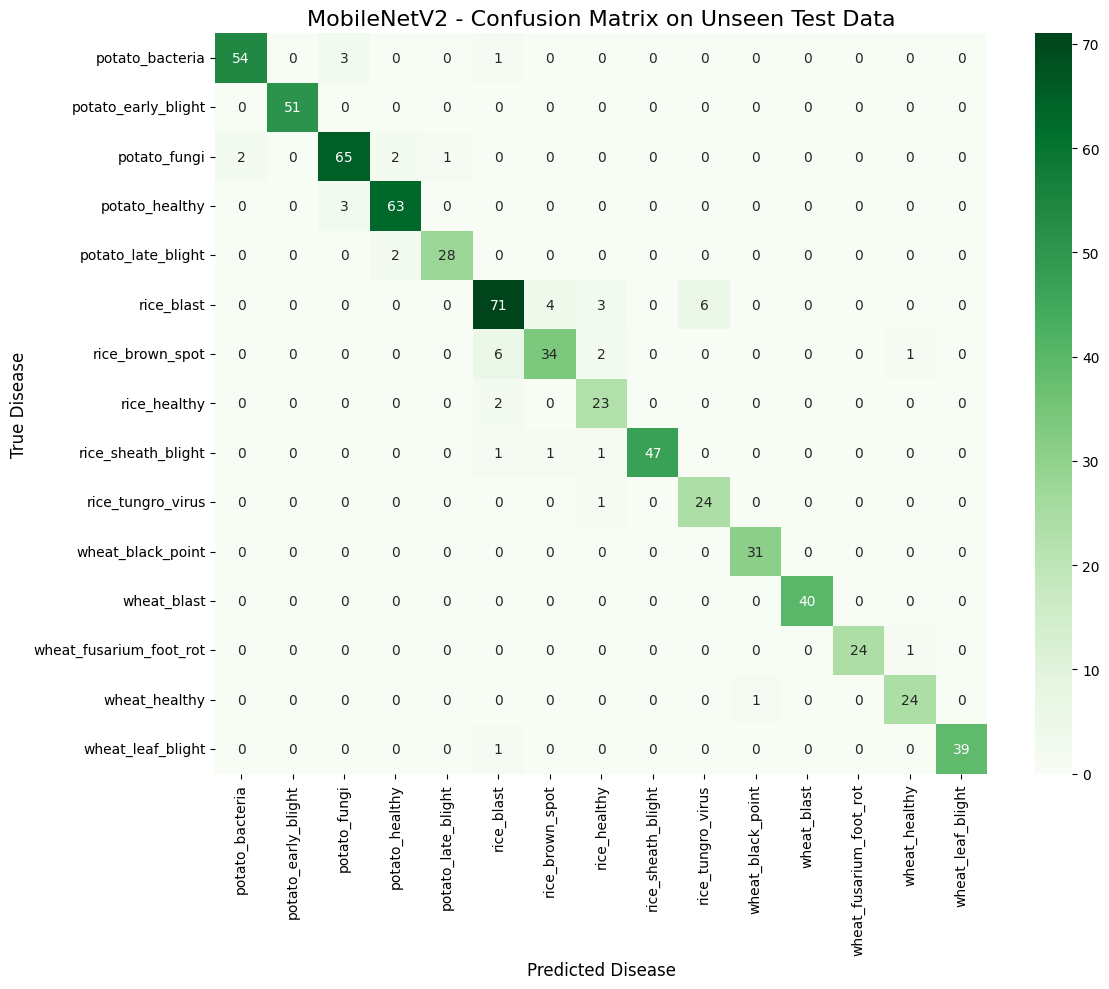

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

print("📝 Initiating Final Exam (Test Set Evaluation) for MobileNetV2...")

# 1. Load the absolute best weights from Phase 2 (Epoch 14)
model_mobile.load_weights(r"D:\00_Thesis_Split\MobileNetV2_FineTuned_Weights.h5")

# 2. Setup the Test Generator (Strictly NO augmentation, NO shuffling)
test_dir = r"D:\00_Thesis_Split\test"
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False 
)

# 3. Get overall Accuracy and Loss
print("\n📊 Running standard evaluation...")
test_loss_mob, test_acc_mob = model_mobile.evaluate(test_generator, verbose=1)
print(f"🏆 MobileNetV2 Unbiased Test Accuracy: {test_acc_mob * 100:.2f}%")

# 4. Generate Predictions for the Detailed Report
print("\n🔍 Generating detailed predictions...")
predictions_mob = model_mobile.predict(test_generator, verbose=1)
y_pred_mob = np.argmax(predictions_mob, axis=1)
y_true_mob = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# 5. Print Classification Report
print("\n--- Thesis Documentation: MobileNetV2 Classification Report ---")
print(classification_report(y_true_mob, y_pred_mob, target_names=class_names))

# 6. Plot and Save the Confusion Matrix
plt.figure(figsize=(12, 10))
cm_mob = confusion_matrix(y_true_mob, y_pred_mob)
sns.heatmap(cm_mob, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('MobileNetV2 - Confusion Matrix on Unseen Test Data', fontsize=16)
plt.ylabel('True Disease', fontsize=12)
plt.xlabel('Predicted Disease', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()

# Save this image directly to your folder for the thesis document
plt.savefig(r"D:\00_Thesis_Split\MobileNetV2_Confusion_Matrix.png")
print("✅ Confusion Matrix saved to D:\\00_Thesis_Split\\MobileNetV2_Confusion_Matrix.png")
plt.show()